In [ ]:
import numpy as np

from grid_engine.toy_data import build_toy_data

In [2]:
gdf = build_toy_data('../tests/toy_datasets/t_tap_test.yaml')
gdf.set_crs(epsg=4326, inplace=True)

,id,name,type,voltage,coords,node_refs,geometry,counts
0,101,sub_JOHN_SEVIER,substation,161000,"[(-83.02, 36.15), (-82.98, 36.15), (-82.98, 36...","[50101, 60101, 60102, 60103, 50101]","POLYGON ((-83.02 36.15, -82.98 36.15, -82.98 3...",NaN
1,102,sub_PHIPPS_BEND,substation,161000,"[(-82.71, 36.44), (-82.69, 36.44), (-82.69, 36...","[50105, 50106, 60105, 50108, 50105]","POLYGON ((-82.71 36.44, -82.69 36.44, -82.69 3...",NaN
2,103,sub_GREENEVILLE,substation,161000,"[(-82.71, 36.14), (-82.69, 36.14), (-82.69, 36...","[50109, 50110, 60109, 50112, 50109]","POLYGON ((-82.71 36.14, -82.69 36.14, -82.69 3...",NaN
3,801,sub_JOHN_SEVIER - J_TOP,line,161000,"[(-83.0, 36.405), (-82.93, 36.415), (-82.86, 3...","[60101, 80101, 80102, 62001]","LINESTRING (-83 36.405, -82.93 36.415, -82.86 ...",1.0
4,802,sub_JOHN_SEVIER - J_MID,line,161000,"[(-83.0, 36.3), (-82.93, 36.3), (-82.86, 36.3)...","[60102, 80201, 80202, 62002]","LINESTRING (-83 36.3, -82.93 36.3, -82.86 36.3...",1.0
5,803,sub_JOHN_SEVIER - J_BOT,line,161000,"[(-83.0, 36.2), (-82.93, 36.19), (-82.86, 36.1...","[60103, 80301, 80302, 62003]","LINESTRING (-83 36.2, -82.93 36.19, -82.86 36....",1.0
6,804,J_MID - J_TOP (Upward Tie),line,161000,"[(-82.8, 36.3), (-82.8, 36.365), (-82.8, 36.43)]","[62002, 80401, 62001]","LINESTRING (-82.8 36.3, -82.8 36.365, -82.8 36...",1.0
7,805,J_MID - J_BOT (Downward Tie),line,161000,"[(-82.8, 36.3), (-82.8, 36.235), (-82.8, 36.17)]","[62002, 80501, 62003]","LINESTRING (-82.8 36.3, -82.8 36.235, -82.8 36...",1.0
8,806,J_TOP - sub_PHIPPS_BEND,line,161000,"[(-82.8, 36.43), (-82.76, 36.438), (-82.73, 36...","[62001, 80601, 80602, 60105]","LINESTRING (-82.8 36.43, -82.76 36.438, -82.73...",2.0
9,807,J_BOT - sub_GREENEVILLE,line,161000,"[(-82.8, 36.17), (-82.76, 36.165), (-82.73, 36...","[62003, 80701, 80702, 60109]","LINESTRING (-82.8 36.17, -82.76 36.165, -82.73...",2.0


In [3]:
line_gdf = gdf[gdf['type'] == 'line']
substation_gdf = gdf[gdf['type'] == 'substation']

In [4]:
line_gdf['confidence'] = np.nan

In [5]:
from grid_engine.engine import GridEngine

GE = GridEngine(line_gdf, substation_gdf, m_buffer=50)

In [6]:
GE.substations_gdf

,id,name,type,voltage,coords,node_refs,geometry,counts
0,101,sub_JOHN_SEVIER,substation,161000,"[(-83.02, 36.15), (-82.98, 36.15), (-82.98, 36...","[50101, 60101, 60102, 60103, 50101]","POLYGON ((-83.02 36.15, -82.98 36.15, -82.98 3...",NaN
1,102,sub_PHIPPS_BEND,substation,161000,"[(-82.71, 36.44), (-82.69, 36.44), (-82.69, 36...","[50105, 50106, 60105, 50108, 50105]","POLYGON ((-82.71 36.44, -82.69 36.44, -82.69 3...",NaN
2,103,sub_GREENEVILLE,substation,161000,"[(-82.71, 36.14), (-82.69, 36.14), (-82.69, 36...","[50109, 50110, 60109, 50112, 50109]","POLYGON ((-82.71 36.14, -82.69 36.14, -82.69 3...",NaN


In [7]:
GE.string_string_adjacency

In [8]:
GE.substation_string_adjacency

In [9]:
G = GE.run()

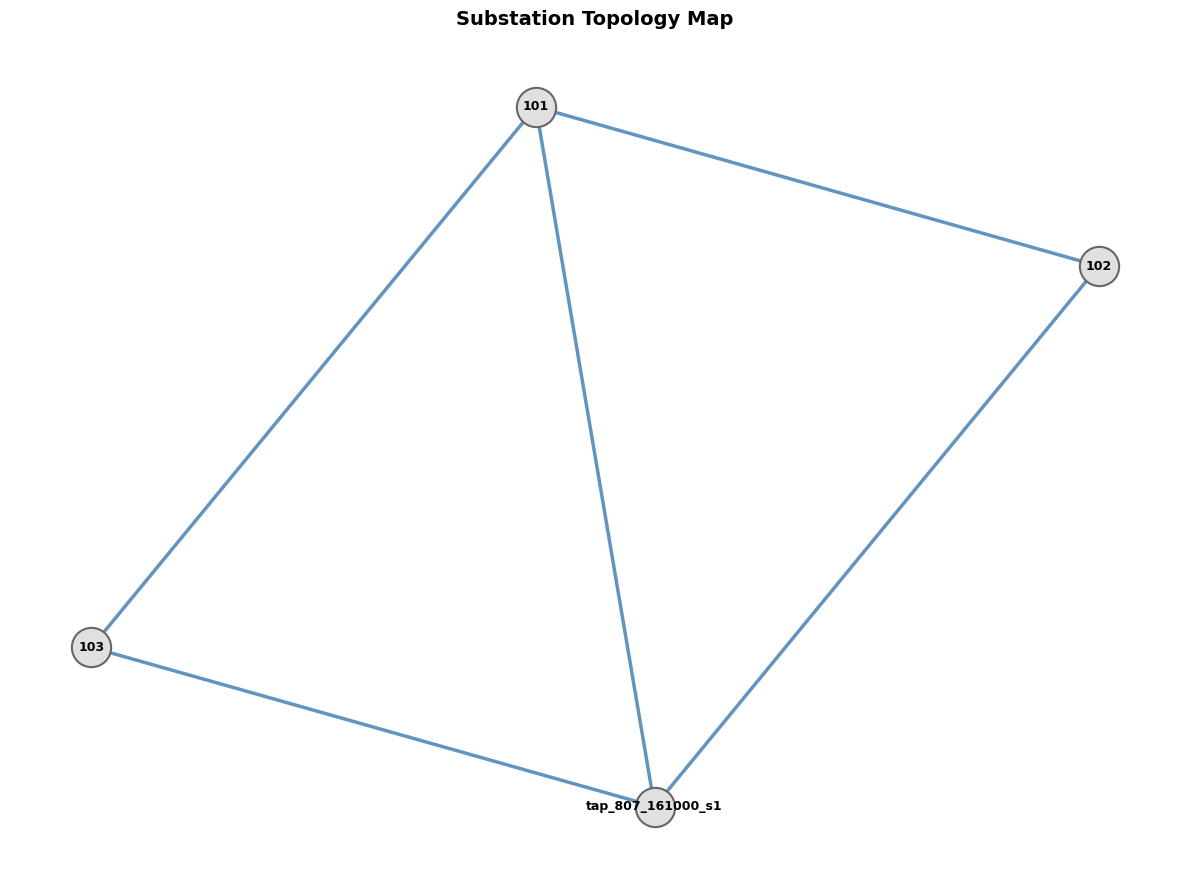

In [10]:
GE.view()